## Find if the O1 SMS have an impact on the ONe-Sleep patients
The goal of this script is to find whether there is an impact of the SMS on the CPAP compliance. The patients are selected by the ONe-Sleep adherence prediction model

### Load dataset

In [85]:
import pandas as pd

# %% Define constant
RAW_DATA_PATH = './data'
measurements_df = pd.read_csv(RAW_DATA_PATH + "/WI_MeasurementWeekly.csv", sep=",")
interventions_df = pd.read_csv(RAW_DATA_PATH + "/Intervention.csv", sep=",")
treatment_df = pd.read_csv(RAW_DATA_PATH + "/Core_Treatment.csv", sep=",")
interventions_df.describe()

,TripId,TreatmentId,Duration,OrderInTrip,LastOptimizationDate,OptimizationCount,Unnamed: 36,Unnamed: 37
count,421.000000,679.000000,576.000000,429.000000,0.0,668.000000,0.0,0.0
mean,202714.147268,102428.410898,26.631944,4.787879,NaN,0.456587,NaN,NaN
std,173186.799817,40595.792510,10.046498,2.851339,NaN,1.441379,NaN,NaN
min,3.000000,1.000000,1.000000,1.000000,NaN,0.000000,NaN,NaN
25%,36511.000000,83422.000000,20.000000,2.000000,NaN,0.000000,NaN,NaN
50%,183183.000000,111834.000000,30.000000,4.000000,NaN,0.000000,NaN,NaN
75%,340399.000000,115545.000000,30.000000,7.000000,NaN,0.000000,NaN,NaN
max,540557.000000,313171.000000,60.000000,13.000000,NaN,5.000000,NaN,NaN


### Select SW treatment that started before 2020

In [86]:
treatment_sw_df = treatment_df.query('Trt_Start_dt > "01-01-2022" & Ther_Id_str.str.contains("SW")', engine='python')
treatment_sw_df.describe()

,Trt_TrtId_int,Trt_RenderedTrtId_int,Trt_CancelationReason_id,Pat_Id_int,Presc_Id_int
count,21.000000,21.000000,1.0,21.000000,21.000000
mean,125389.761905,1.047619,1.0,29303.095238,10594.761905
std,25408.919878,0.218218,NaN,23537.714900,11819.638217
min,110262.000000,1.000000,1.0,4480.000000,465.000000
25%,111696.000000,1.000000,1.0,6719.000000,736.000000
50%,114825.000000,1.000000,1.0,28205.000000,2788.000000
75%,137533.000000,1.000000,1.0,42149.000000,24189.000000
max,223405.000000,2.000000,1.0,79682.000000,29573.000000


### Get measurements for patients for the previsouly selected treatment
Select also only the measurements which have enough data

In [87]:
measurments_sw_bool = measurements_df['Pat_Id_int'].isin(treatment_sw_df['Pat_Id_int'])
measurments_sw_df = measurements_df[measurments_sw_bool]
measurments_sw_df = measurments_sw_df.query('MeasW_YearWeek_int < 202001 & MeasW_YearWeek_int > 201852', engine='python')
measurments_sw_df

,MeasW_Id_str,Pat_Id_int,MeasW_YearWeek_int,MeasW_NbDays_int,MeasW_MeasurementCompliance_ft,MeasW_MeasurementLeak_ft,MeasW_MeasurementLeakUnit_str,MeasW_MeasurementAHI_ft,MeasW_LoadedOn_dt
64,13917_201901,13917.0,201901.0,7.0,5.92,2.23,l/min,0.49,2020-01-02
65,13917_201902,13917.0,201902.0,7.0,1.57,0.00,%,0.23,2019-01-17
66,13917_201903,13917.0,201903.0,6.0,4.85,0.00,%,0.87,2019-01-25
67,13917_201904,13917.0,201904.0,6.0,1.50,0.25,%,1.28,2019-02-01
68,13917_201905,13917.0,201905.0,7.0,0.00,NaN,%,NaN,2019-02-08
...,...,...,...,...,...,...,...,...,...
4878,79682_201948,79682.0,201948.0,7.0,5.15,79.03,l/min,2.50,2019-12-05
4879,79682_201949,79682.0,201949.0,7.0,5.03,74.23,l/min,2.04,2019-12-12
4880,79682_201950,79682.0,201950.0,7.0,5.24,76.11,l/min,1.39,2019-12-23
4881,79682_201951,79682.0,201951.0,7.0,4.86,89.66,l/min,1.30,2019-12-27


### Get all internvetions O1 interventions

In [88]:
interventions_df['TRCRealizationDate'] = interventions_df['TRCRealizationDate'].fillna(pd.Timestamp.max)
interventions_df['TRCRealizationDate'] =  pd.to_datetime(interventions_df['TRCRealizationDate'], errors = 'coerce', format='%Y-%m-%d')
interventions_df = interventions_df[interventions_df['TreatmentId'].notna()]
interventions_O1_df = interventions_df.query('Status == "E" & Therapy.str.contains("SW") & ServiceType.str.contains("O1")', engine= 'python')
# Remove patient having two internvetions
interventions_O1_df = interventions_O1_df.drop_duplicates(subset=['PatientId'], keep=False)
# interventions_O1_df = interventions_O1_df[interventions_O1_df['PatientId'].isin(treatment_sw_df['Pat_Id_int'])]
# interventions_O1_df['TRCRealizationDate'] = interventions_O1_df['TRCRealizationDate'].dt.normalize()
interventions_O1_df['PatientId'] = interventions_O1_df['PatientId'].astype(int)
interventions_O1_df

,InterventionId,PatientId,RegionId,AddressId,TripId,TreatmentId,RenderedTreatmentId,Site,ForecastedDate,Agreed,...,OnHoldUntil,NewTttReason,SmsStatus,TRCRealizationDate,ModemIssue,NoModem,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37
34,5023999,4480,9209,1,NaN,111696.0,1,1,15:38.6,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN
85,5024004,4553,9209,1,NaN,114825.0,1,1,15:50.5,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN
121,5023994,5930,9209,1,NaN,110262.0,1,1,15:34.2,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN
164,5023997,6058,9209,1,NaN,110787.0,1,1,15:37.5,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN
206,5024010,6719,9209,1,NaN,138294.0,1,1,15:54.9,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN
251,5024007,7680,9209,1,NaN,115545.0,1,1,15:52.0,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN
298,5024003,7697,9209,1,NaN,114527.0,1,1,15:50.1,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN
330,5023996,13917,9209,1,NaN,110763.0,1,1,15:36.8,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN
368,5024011,26632,9209,1,NaN,138965.0,1,1,15:55.7,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN
396,5024002,28205,9209,1,NaN,113649.0,1,1,15:40.0,N,...,NaN,NaN,NaN,2262-04-11 23:47:16.854775807,NaN,NaN,NaN,NaN,NaN,NaN


### Build measurements by patients

In [89]:
measurments_sw_df =  measurments_sw_df[measurments_sw_df.Pat_Id_int.isin(interventions_O1_df.PatientId)]
measurments_sw_df
measurments_sw_df['Week'] = measurments_sw_df.MeasW_YearWeek_int.astype(str).str[4:6]
measurments_sw_df['Week'] = measurments_sw_df['Week'].astype(int)
n_by_patient = measurments_sw_df.groupby("Pat_Id_int").count()
n_by_patient = n_by_patient[n_by_patient['MeasW_MeasurementCompliance_ft'] == 52]
measurments_sw_df = measurments_sw_df[measurments_sw_df.Pat_Id_int.isin(n_by_patient.index)]
measurments_pivot_df = pd.pivot_table(measurments_sw_df,
                                       index=['Pat_Id_int'],
                                       columns='Week',
                                       values=['MeasW_MeasurementCompliance_ft'], aggfunc='first')
measurments_pivot_df.columns = measurments_pivot_df.columns.get_level_values(1)
measurments_pivot_df['PatientId'] = measurments_pivot_df.index
measurments_pivot_df

Week,1,2,3,4,5,6,7,8,9,10,...,44,45,46,47,48,49,50,51,52,PatientId
Pat_Id_int,,,,,,,,,,,,,,,,,,,,,
4480.0,8.90,7.95,8.20,8.61,9.37,7.92,6.95,7.56,8.16,7.53,...,7.71,7.91,7.97,8.92,6.28,7.65,6.80,6.71,7.26,4480.0
5930.0,6.63,7.00,6.34,6.36,6.87,6.97,6.52,6.83,6.89,6.70,...,6.65,6.54,6.87,6.78,6.62,6.54,6.64,6.80,6.60,5930.0
7680.0,3.98,2.89,4.78,4.32,3.67,5.32,5.95,5.94,3.94,5.18,...,4.49,4.87,3.20,5.91,5.87,5.20,3.95,5.65,6.01,7680.0
7697.0,7.50,7.55,6.83,7.83,8.17,7.25,6.82,8.30,7.97,8.06,...,7.11,6.70,5.02,7.79,7.62,7.44,7.33,6.73,8.12,7697.0
13917.0,5.92,1.57,4.85,1.50,0.00,0.00,2.83,1.24,4.84,5.93,...,5.81,5.61,4.60,8.91,4.75,5.65,5.56,5.15,5.51,13917.0
34718.0,4.20,3.52,4.52,4.43,7.07,5.53,5.71,5.00,4.89,4.82,...,4.60,3.27,3.50,3.73,4.99,4.52,4.45,3.84,4.82,34718.0
35703.0,5.96,6.49,6.23,6.20,6.26,4.04,6.86,6.98,5.92,6.16,...,6.24,5.72,6.19,6.67,6.22,6.38,6.38,6.18,6.75,35703.0
37340.0,10.25,10.66,10.34,10.75,10.08,11.08,10.24,10.59,10.07,10.06,...,10.34,11.05,10.66,10.73,10.44,10.04,8.04,8.25,10.34,37340.0
44359.0,4.31,4.13,2.80,4.24,3.49,3.72,1.23,3.33,3.59,4.66,...,3.94,4.40,4.58,3.14,4.71,2.02,3.80,4.89,2.78,44359.0


### Add intervention with measurement

In [90]:
measurments_intervention_df = pd.merge(measurments_pivot_df,interventions_O1_df[['PatientId','TRCRealizationDate', 'ServiceType']],on='PatientId', how='inner')
measurments_intervention_df['TRCRealizationDate'] = measurments_intervention_df['TRCRealizationDate'].dt.normalize()
measurments_intervention_df['Intervention_week'] = measurments_intervention_df['TRCRealizationDate'].dt.week

measurments_intervention_df['compliance_yearly_average'] = measurments_intervention_df.iloc[:, 0:52].mean(axis=1)
measurments_intervention_df.describe()

<ipython-input-90-bbf03bf21218>:3: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  measurments_intervention_df['Intervention_week'] = measurments_intervention_df['TRCRealizationDate'].dt.week


,1,2,3,4,5,6,7,8,9,10,...,46,47,48,49,50,51,52,PatientId,Intervention_week,compliance_yearly_average
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,...,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.0,13.000000
mean,6.070000,5.730769,5.882308,5.895385,6.088462,5.967692,5.866923,6.206154,6.063077,6.370769,...,5.871538,6.749231,6.174615,6.223846,5.860769,6.054615,6.457692,34981.076923,15.0,6.153121
std,1.954039,2.557689,2.170446,2.467811,2.673190,2.620643,2.198145,2.351611,1.851857,1.613565,...,2.101570,2.081652,1.616032,1.937557,1.429262,1.278193,1.874469,25912.951786,0.0,1.805083
min,3.760000,1.570000,2.120000,1.500000,0.000000,0.000000,1.230000,1.240000,3.590000,3.890000,...,3.200000,3.140000,4.390000,2.020000,3.800000,3.840000,2.780000,4480.000000,15.0,3.955385
25%,4.310000,3.860000,4.780000,4.320000,4.880000,4.870000,4.930000,5.000000,4.840000,5.180000,...,4.580000,5.720000,4.990000,5.200000,4.450000,5.150000,5.510000,7697.000000,15.0,4.661923
50%,5.920000,6.490000,6.230000,6.200000,6.800000,6.320000,6.410000,6.830000,5.920000,6.530000,...,5.020000,6.780000,6.090000,6.380000,6.380000,6.180000,6.600000,35703.000000,15.0,6.255577
75%,6.740000,7.550000,6.830000,7.380000,7.090000,7.250000,6.860000,7.550000,6.890000,6.700000,...,7.040000,7.790000,6.620000,7.440000,6.880000,6.730000,7.260000,49144.000000,15.0,7.041154
max,10.250000,10.660000,10.340000,10.750000,10.080000,11.080000,10.240000,10.590000,10.070000,10.060000,...,10.660000,10.730000,10.440000,10.040000,8.040000,8.250000,10.340000,79682.000000,15.0,10.405385


### Get measurements 3 months before and after the intervention week

In [91]:
def get_forward_weeks(week_number, number_forward_weeks):
    res = []
    for i in week_number:
        forward_week = i + number_forward_weeks
        res.append(forward_week)
    return res

def get_prev_weeks(week_number, number_prev_weeks):
    res = []
    for i in week_number:
        prev_week = i - number_prev_weeks
        res.append(prev_week)
    return res

interventions_O1_df['TRCRealizationDate'] = interventions_O1_df['TRCRealizationDate'].dt.normalize()
interventions_O1_df['W'] = interventions_O1_df['TRCRealizationDate'].dt.week
NUMBER_WEEKS = 6

interventions_O1_df = interventions_O1_df.rename(columns={'PatientId': 'Pat_Id_int'})
measurements_history_df = interventions_O1_df[['Pat_Id_int']]

for i in range(1, NUMBER_WEEKS):
    interventions_O1_df['W-' + str(i)] = get_prev_weeks(interventions_O1_df['W'], i)
    interventions_O1_df['W+' + str(i)] = get_forward_weeks(interventions_O1_df['W'], i)

for i in range(1, NUMBER_WEEKS):
    previous_tmp_df = pd.merge(interventions_O1_df[['Pat_Id_int', 'W-' + str(i)]],
                        measurments_sw_df[['Pat_Id_int', 'MeasW_MeasurementCompliance_ft', 'Week']],
                        how='inner',
                        left_on=['Pat_Id_int', 'W-' + str(i)],
                        right_on=['Pat_Id_int', 'Week'])
    previous_tmp_df = previous_tmp_df.drop(['Week', 'W-' + str(i)], axis=1)
    previous_tmp_df = previous_tmp_df.rename(columns={'MeasW_MeasurementCompliance_ft': 'Compliance_W-' + str(i)})

    measurements_history_df = pd.merge(measurements_history_df, previous_tmp_df, how='inner', on=['Pat_Id_int'])

    previous_tmp_df = pd.merge(interventions_O1_df[['Pat_Id_int', 'W+' + str(i)]],
                        measurments_sw_df[['Pat_Id_int', 'MeasW_MeasurementCompliance_ft', 'Week']],
                        how='inner',
                        left_on=['Pat_Id_int', 'W+' + str(i)],
                        right_on=['Pat_Id_int', 'Week'])
    previous_tmp_df = previous_tmp_df.drop(['Week', 'W+' + str(i)], axis=1)
    previous_tmp_df = previous_tmp_df.rename(columns={'MeasW_MeasurementCompliance_ft': 'Compliance_W+' + str(i)})

    measurements_history_df = pd.merge(measurements_history_df, previous_tmp_df, how='inner', on=['Pat_Id_int'])

previous_tmp_df = pd.merge(interventions_O1_df[['Pat_Id_int', 'W']],
                        measurments_sw_df[['Pat_Id_int', 'MeasW_MeasurementCompliance_ft', 'Week']],
                        how='inner',
                        left_on=['Pat_Id_int', 'W'],
                        right_on=['Pat_Id_int', 'Week'])
previous_tmp_df = previous_tmp_df.drop(['Week', 'W'], axis=1)
previous_tmp_df = previous_tmp_df.rename(columns={'MeasW_MeasurementCompliance_ft': 'Compliance_W'})

measurements_history_df = pd.merge(measurements_history_df, previous_tmp_df, how='inner', on=['Pat_Id_int'])
measurements_history_df.head()

<ipython-input-91-47465217e48e>:16: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  interventions_O1_df['W'] = interventions_O1_df['TRCRealizationDate'].dt.week


,Pat_Id_int,Compliance_W-1,Compliance_W+1,Compliance_W-2,Compliance_W+2,Compliance_W-3,Compliance_W+3,Compliance_W-4,Compliance_W+4,Compliance_W-5,Compliance_W+5,Compliance_W
0,4480,8.93,8.29,7.98,7.88,7.35,8.24,7.87,7.52,7.53,8.33,8.80
1,5930,6.38,6.75,6.55,6.70,6.95,7.05,6.80,7.01,6.70,6.39,6.40
2,7680,5.71,6.87,5.26,5.97,6.05,5.26,5.08,2.99,5.18,5.17,6.06
3,7697,7.10,7.33,6.40,7.06,6.96,6.90,7.34,6.54,8.06,7.11,7.22
4,13917,4.57,6.13,5.29,5.95,5.16,6.13,4.51,6.14,5.93,5.85,4.57


### Plot low compliance

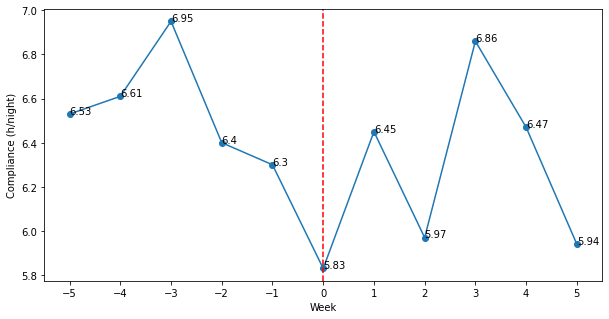

In [92]:
import matplotlib.pyplot as plt

def get_compliance_mean(df):
    before = pd.DataFrame()
    after = pd.DataFrame()
    for i in range(1, NUMBER_WEEKS):
        before = before.append({'x': '-' + str(i),
                                'y': df['Compliance_W-' + str(i)].astype(
                                    float).median()}, ignore_index=True)
        after = after.append({'x': '' + str(i),
                              'y': df['Compliance_W+' + str(i)].astype(
                                  float).median()}, ignore_index=True)
    before.x = before.x.astype(int)
    after.x = after.x.astype(int)
    before = before.sort_values('x', ascending=True)
    result = pd.concat([before, pd.DataFrame(
        [[0, df['Compliance_W'].astype(float).median()]], columns=['x', 'y'])],
                       axis=0)
    result = pd.concat([result, after], axis=0)

    return result

mean_low_compliance = get_compliance_mean(measurements_history_df)
plt.plot(mean_low_compliance.x, mean_low_compliance.y, marker='o')
plt.rcParams["figure.figsize"] = (10,5)
plt.axvline(x=0, color='r', linestyle='dashed')
plt.xticks(mean_low_compliance.x)
plt.ylabel('Compliance (h/night)')
plt.xlabel('Week')
for i, j in zip(mean_low_compliance.x, mean_low_compliance.y):
    plt.annotate(str(round(j, 2)), xy=(i, j))
plt.show()